   Row_ID  Year                          Era     Scenario         Region  \
0       1  2064   Symbiotic Intelligence Age  Pessimistic      East Asia   
1       2  2029       AI Mainstream Adoption        Mixed  Latin America   
2       3  2047  Post-Singularity Transition      Neutral  Latin America   
3       4  2069   Symbiotic Intelligence Age      Neutral      East Asia   
4       5  2048  Post-Singularity Transition   Optimistic     South Asia   

     Demographic_Group Education_Level          Profession  \
0  Young Adult (26-35)   Undergraduate          Technology   
1       Senior (51-65)   Undergraduate          Healthcare   
2        Youth (18-25)       Secondary  Science & Research   
3       Senior (51-65)    PhD/Research          Technology   
4  Young Adult (26-35)   Undergraduate    Entrepreneurship   

       AI_Tool_Category  Weekly_AI_Usage_Hours  ...  \
0    AGI-Adjacent Tools                   28.2  ...   
1                   NaN                   10.0  ...   
2    

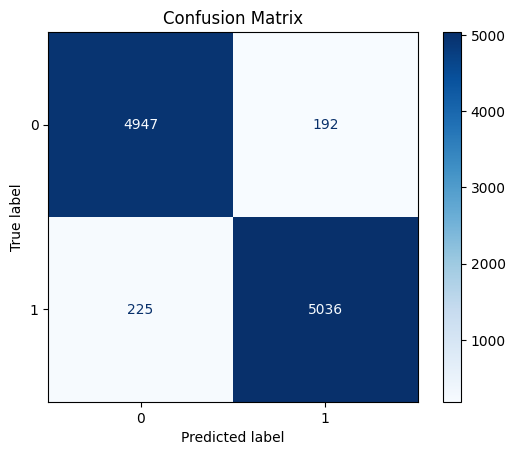


Classification Report
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      5139
           1       0.96      0.96      0.96      5261

    accuracy                           0.96     10400
   macro avg       0.96      0.96      0.96     10400
weighted avg       0.96      0.96      0.96     10400


AUC Score : 0.9952


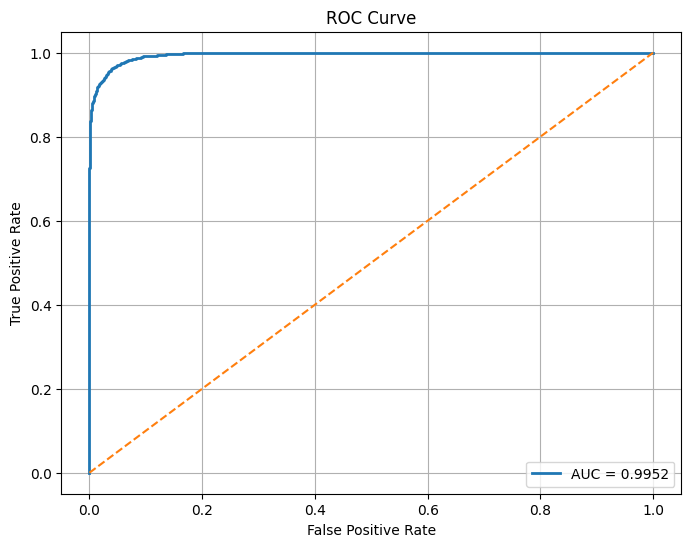


First 10 Predictions
   Actual  Predicted   Probability
0       0          0  3.221165e-08
1       0          0  2.827600e-10
2       1          1  9.975262e-01
3       0          0  1.457288e-06
4       0          0  1.317767e-05
5       1          1  9.999839e-01
6       1          1  9.999997e-01
7       1          1  9.999976e-01
8       0          0  5.271144e-09
9       0          0  5.931604e-02

Prediction table saved.
Confusion matrix saved.

Threshold Performance
   Threshold  Precision    Recall  F1 Score
0        0.3   0.941424  0.977571  0.959157
1        0.4   0.953245  0.968827  0.960973
2        0.5   0.963275  0.957232  0.960244
3        0.6   0.970514  0.944687  0.957426
4        0.7   0.977818  0.930051  0.953337

Best Threshold Based on F1 Score
Threshold    0.400000
Precision    0.953245
Recall       0.968827
F1 Score     0.960973
Name: 1, dtype: float64




MODEL COMPARISON
                          Model  Precision    Recall  F1 Score       AUC
0   Logistic Regr

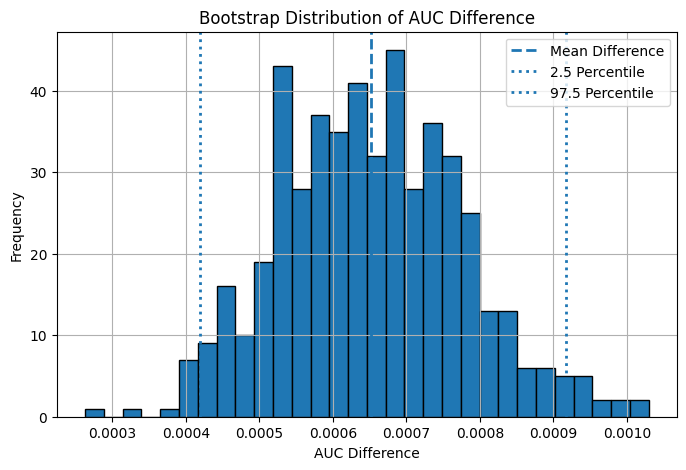


Bootstrap results saved successfully.


In [3]:

# Data Preprocessing

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Load Dataset

df = pd.read_csv("cleaned_data.csv")

print(df.head())


# Target Variables
# Regression Target
y_reg = df["AI_Dependency_Score"]

# Classification Target
y_clf = (
    df["AI_Dependency_Score"] >
    df["AI_Dependency_Score"].median()
).astype(int)

print("\nRegression Target : AI_Dependency_Score")

print("\nClassification Target Distribution")

print(y_clf.value_counts())


# Feature Matrix


X = df.drop(
    columns=[
        "AI_Dependency_Score",
        "Row_ID"
    ]
)

print("\nFeature Matrix Shape")

print(X.shape)


# Fill Missing Values


categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns

for col in categorical_columns:
    X[col] = X[col].fillna("Unknown")

print("\nMissing values handled.")


# Ordinal Encoding


education_order = {
    "Primary": 1,
    "Secondary": 2,
    "Higher Secondary": 3,
    "Diploma": 4,
    "Undergraduate": 5,
    "Postgraduate": 6,
    "PhD/Research": 7
}

era_order = {
    "AI Emergence": 1,
    "AI Mainstream Adoption": 2,
    "Human-AI Collaboration Boom": 3,
    "Post-Singularity Transition": 4,
    "Symbiotic Intelligence Age": 5
}

if "Education_Level" in X.columns:

    X["Education_Level"] = X["Education_Level"].map(
        education_order
    )

    X["Education_Level"] = X["Education_Level"].fillna(
        X["Education_Level"].median()
    )

if "Era" in X.columns:

    X["Era"] = X["Era"].map(
        era_order
    )

    X["Era"] = X["Era"].fillna(
        X["Era"].median()
    )

print("\nOrdinal Encoding Completed.")


# Remove High Cardinality Columns


high_cardinality_columns = [

    "Positive_Effects_of_AI",

    "Negative_Effects_of_AI"

]

X.drop(
    columns=high_cardinality_columns,
    inplace=True
)

print("\nDropped High Cardinality Columns")

print(high_cardinality_columns)


# One-Hot Encoding

nominal_columns = [

    "Scenario",

    "Region",

    "Demographic_Group",

    "Profession",

    "AI_Tool_Category",

    "Outcome_Label"

]

X = pd.get_dummies(

    X,

    columns=nominal_columns,

    drop_first=True,

    dtype="uint8"

)

print("\nShape After One Hot Encoding")

print(X.shape)


# Train-Test Split

X_train_reg, X_test_reg, y_reg_train, y_reg_test = train_test_split(

    X,

    y_reg,

    test_size=0.20,

    random_state=42

)

X_train_clf, X_test_clf, y_clf_train, y_clf_test = train_test_split(

    X,

    y_clf,

    test_size=0.20,

    random_state=42

)

print("\nRegression Train Shape :", X_train_reg.shape)
print("Regression Test Shape :", X_test_reg.shape)

print("\nClassification Train Shape :", X_train_clf.shape)
print("Classification Test Shape :", X_test_clf.shape)


# Feature Scaling

scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(

    X_train_reg

)

X_test_reg_scaled = scaler_reg.transform(

    X_test_reg

)

scaler_clf = StandardScaler()

X_train_clf_scaled = scaler_clf.fit_transform(

    X_train_clf

)

X_test_clf_scaled = scaler_clf.transform(

    X_test_clf

)

print("\nScaling Completed Successfully")

# Linear Regression & Ridge Regression


import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Linear Regression


linear_model = LinearRegression()

linear_model.fit(
    X_train_reg_scaled,
    y_reg_train
)

# Prediction

y_pred_reg = linear_model.predict(
    X_test_reg_scaled
)

# Evaluation

mse_linear = mean_squared_error(
    y_reg_test,
    y_pred_reg
)

r2_linear = r2_score(
    y_reg_test,
    y_pred_reg
)

print("\nLinear Regression Results")
print(f"MSE      : {mse_linear:.4f}")
print(f"R² Score : {r2_linear:.4f}")


# Feature Importance (Coefficients)


coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coef_df["Absolute_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("\nTop 10 Features by Absolute Coefficient")
print(coef_df.head(10))

print("\nTop 3 Most Important Features")

top3 = coef_df.head(3)

for i, row in top3.iterrows():

    print("Feature :", row["Feature"])
    print("Coefficient :", round(row["Coefficient"],4))

    if row["Coefficient"] > 0:

        print("Interpretation :")
        print("Increasing this standardized feature by one unit increases the predicted AI_Dependency_Score.")

    else:

        print("Interpretation :")
        print("Increasing this standardized feature by one unit decreases the predicted AI_Dependency_Score.")


# Ridge Regression

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train_reg_scaled,
    y_reg_train
)

ridge_pred = ridge_model.predict(
    X_test_reg_scaled
)

mse_ridge = mean_squared_error(
    y_reg_test,
    ridge_pred
)

r2_ridge = r2_score(
    y_reg_test,
    ridge_pred
)

print("\n")

print(f"MSE      : {mse_ridge:.4f}")
print(f"R² Score : {r2_ridge:.4f}")

# Ridge Coefficients

ridge_coef = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": ridge_model.coef_

})

ridge_coef["Absolute_Coefficient"] = ridge_coef["Coefficient"].abs()

ridge_coef = ridge_coef.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("\nTop 10 Ridge Features")

print(ridge_coef.head(10))


# Model Comparison

comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge Regression"
    ],

    "MSE":[
        mse_linear,
        mse_ridge
    ],

    "R2 Score":[
        r2_linear,
        r2_ridge
    ]

})

print("\n")
print("MODEL COMPARISON")

print(comparison)


# Save Results

coef_df.to_csv(
    "linear_regression_coefficients.csv",
    index=False
)

ridge_coef.to_csv(
    "ridge_regression_coefficients.csv",
    index=False
)

comparison.to_csv(
    "regression_model_comparison.csv",
    index=False
)

print("\nCSV files saved successfully.")


# Logistic Regression Classification

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Class Distribution


print("\nTraining Class Distribution")

before_counts = y_clf_train.value_counts().sort_index()

print(before_counts)

before_percentage = y_clf_train.value_counts(normalize=True)*100

print("\nTraining Class Percentage")

print(before_percentage)


# Check Imbalance

minority_percentage = before_percentage.min()

if minority_percentage < 35:

    print("\nImbalanced Dataset Detected")

    logistic_model = LogisticRegression(

        class_weight="balanced",

        max_iter=1000,

        random_state=42

    )

    imbalance_method = "class_weight='balanced'"

else:

    print("\nDataset is Balanced")

    logistic_model = LogisticRegression(

        max_iter=1000,

        random_state=42

    )

    imbalance_method = "No balancing required"

print("\nMethod Used :", imbalance_method)


# Train Model

logistic_model.fit(

    X_train_clf_scaled,

    y_clf_train

)

print("\nModel Training Completed")


# After Counts

after_counts = y_clf_train.value_counts().sort_index()

comparison = pd.DataFrame({

    "Before":before_counts,

    "After":after_counts

})

print("\nBefore/After Class Count")

print(comparison)


# Prediction

y_pred_clf = logistic_model.predict(

    X_test_clf_scaled

)

y_prob = logistic_model.predict_proba(

    X_test_clf_scaled

)[:,1]


# Evaluation Metrics


accuracy = accuracy_score(

    y_clf_test,

    y_pred_clf

)

precision = precision_score(

    y_clf_test,

    y_pred_clf

)

recall = recall_score(

    y_clf_test,

    y_pred_clf

)

f1 = f1_score(

    y_clf_test,

    y_pred_clf

)

print("\n")

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")


# Confusion Matrix


cm = confusion_matrix(

    y_clf_test,

    y_pred_clf

)

print("\nConfusion Matrix")

print(cm)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm

)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

# Classification Report


print("\nClassification Report")

print(

    classification_report(

        y_clf_test,

        y_pred_clf

    )

)


# ROC Curve

fpr, tpr, thresholds = roc_curve(

    y_clf_test,

    y_prob

)

auc = roc_auc_score(

    y_clf_test,

    y_prob

)

print("\nAUC Score :", round(auc,4))

plt.figure(figsize=(8,6))

plt.plot(

    fpr,

    tpr,

    linewidth=2,

    label=f"AUC = {auc:.4f}"

)

plt.plot(

    [0,1],

    [0,1],

    linestyle="--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()


# Prediction Sample

prediction_table = pd.DataFrame({

    "Actual":y_clf_test.values,

    "Predicted":y_pred_clf,

    "Probability":y_prob

})

print("\nFirst 10 Predictions")

print(prediction_table.head(10))


# Save Results

prediction_table.to_csv(

    "logistic_predictions.csv",

    index=False

)

pd.DataFrame(cm).to_csv(

    "confusion_matrix.csv",

    index=False

)

print("\nPrediction table saved.")

print("Confusion matrix saved.")

# Threshold Sensitivity & Logistic Regularization


import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


# Threshold Analysis

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

print("\nThreshold Performance")

for threshold in thresholds:

    predictions = (y_prob >= threshold).astype(int)

    precision = precision_score(
        y_clf_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_clf_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_clf_test,
        predictions,
        zero_division=0
    )

    threshold_results.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_table = pd.DataFrame(

    threshold_results,

    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1 Score"
    ]

)

print(threshold_table)


# Best Threshold

best_threshold = threshold_table.loc[
    threshold_table["F1 Score"].idxmax()
]

print("\nBest Threshold Based on F1 Score")

print(best_threshold)


# Logistic Regression with Strong Regularization

print("\n")

# Use same imbalance strategy as Part 3

if minority_percentage < 35:

    logistic_regularized = LogisticRegression(

        C=0.01,

        class_weight="balanced",

        max_iter=1000,

        random_state=42

    )

else:

    logistic_regularized = LogisticRegression(

        C=0.01,

        max_iter=1000,

        random_state=42

    )

logistic_regularized.fit(

    X_train_clf_scaled,

    y_clf_train

)


# Prediction

regularized_prediction = logistic_regularized.predict(

    X_test_clf_scaled

)

regularized_probability = logistic_regularized.predict_proba(

    X_test_clf_scaled

)[:,1]


# Metrics

baseline_precision = precision_score(

    y_clf_test,

    y_pred_clf

)

baseline_recall = recall_score(

    y_clf_test,

    y_pred_clf

)

baseline_f1 = f1_score(

    y_clf_test,

    y_pred_clf

)

baseline_auc = roc_auc_score(

    y_clf_test,

    y_prob

)

regularized_precision = precision_score(

    y_clf_test,

    regularized_prediction

)

regularized_recall = recall_score(

    y_clf_test,

    regularized_prediction

)

regularized_f1 = f1_score(

    y_clf_test,

    regularized_prediction

)

regularized_auc = roc_auc_score(

    y_clf_test,

    regularized_probability

)


# Comparison Table

comparison_table = pd.DataFrame({

    "Model":[

        "Logistic Regression (C=1.0)",

        "Logistic Regression (C=0.01)"

    ],

    "Precision":[

        baseline_precision,

        regularized_precision

    ],

    "Recall":[

        baseline_recall,

        regularized_recall

    ],

    "F1 Score":[

        baseline_f1,

        regularized_f1

    ],

    "AUC":[

        baseline_auc,

        regularized_auc

    ]

})

print("\n")
print("MODEL COMPARISON")

print(comparison_table)

# Better Model

if baseline_auc > regularized_auc:

    print("\nBaseline Logistic Regression (C=1.0) performs better.")

elif baseline_auc < regularized_auc:

    print("\nRegularized Logistic Regression (C=0.01) performs better.")

else:

    print("\nBoth models have similar AUC.")


# Save Results

threshold_table.to_csv(

    "threshold_results.csv",

    index=False

)

comparison_table.to_csv(

    "logistic_regularization_comparison.csv",

    index=False

)

print("\nThreshold results saved.")

print("Regularization comparison saved.")


# Bootstrap Confidence Interval for AUC Difference

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score


# Bootstrap Parameters

np.random.seed(42)

n_bootstrap = 500

auc_difference = []

# Convert to numpy arrays

y_true = np.array(y_clf_test)

baseline_prob = np.array(y_prob)

regularized_prob = np.array(regularized_probability)


# Bootstrap Sampling


for i in range(n_bootstrap):

    indices = np.random.choice(

        len(y_true),

        size=len(y_true),

        replace=True

    )

    y_sample = y_true[indices]

    baseline_sample = baseline_prob[indices]

    regularized_sample = regularized_prob[indices]

    # Skip samples containing only one class

    if len(np.unique(y_sample)) < 2:
        continue

    auc_baseline = roc_auc_score(

        y_sample,

        baseline_sample

    )

    auc_regularized = roc_auc_score(

        y_sample,

        regularized_sample

    )

    auc_difference.append(

        auc_baseline - auc_regularized

    )

auc_difference = np.array(auc_difference)


# Confidence Interval


mean_difference = np.mean(auc_difference)

lower_bound = np.percentile(

    auc_difference,

    2.5

)

upper_bound = np.percentile(

    auc_difference,

    97.5

)

print("\nMean AUC Difference")

print(round(mean_difference,6))

print("\n95% Confidence Interval")

print(f"Lower Bound : {lower_bound:.6f}")

print(f"Upper Bound : {upper_bound:.6f}")


# Interpretation

print("\nInterpretation")

if lower_bound > 0 or upper_bound < 0:

    print("The confidence interval excludes zero.")

    print("The difference between the two models is statistically reliable.")

else:

    print("The confidence interval includes zero.")

    print("The observed difference may not be statistically reliable.")


# Save Results

bootstrap_summary = pd.DataFrame({

    "Mean_AUC_Difference":[mean_difference],

    "Lower_95_CI":[lower_bound],

    "Upper_95_CI":[upper_bound]

})

bootstrap_summary.to_csv(

    "bootstrap_auc_summary.csv",

    index=False

)

bootstrap_values = pd.DataFrame({

    "AUC_Difference":auc_difference

})

bootstrap_values.to_csv(

    "bootstrap_auc_values.csv",

    index=False

)


# Histogram

plt.figure(figsize=(8,5))

plt.hist(

    auc_difference,

    bins=30,

    edgecolor="black"

)

plt.axvline(

    mean_difference,

    linestyle="--",

    linewidth=2,

    label="Mean Difference"

)

plt.axvline(

    lower_bound,

    linestyle=":",

    linewidth=2,

    label="2.5 Percentile"

)

plt.axvline(

    upper_bound,

    linestyle=":",

    linewidth=2,

    label="97.5 Percentile"

)

plt.title("Bootstrap Distribution of AUC Difference")

plt.xlabel("AUC Difference")

plt.ylabel("Frequency")

plt.legend()

plt.grid(True)

plt.show()

print("\nBootstrap results saved successfully.")
